# Notebook 09 — Direct Price Forecasting

Every earlier notebook predicts a *property* of tomorrow: its direction (NB05–07)
or its volatility (NB08). This one answers the question the project actually
started from:

> **What will the EUR/USD price be at the next close?**

The model outputs a concrete price, and it is scored the way a user would score
it: a forecast is **correct** when it lands within a stated tolerance of the
real close. Tolerance is measured in **pips** (1 pip = 0.0001).

Three things are established here, in order:

1. the model must learn a **return**, not a price level, and why;
2. how accurate the price forecast is, at every tolerance;
3. the honest comparison that decides whether any of it is skill — against the
   do-nothing rule **"tomorrow = today"**.

Method is identical to the rest of the project: the same 31 features, the same
strictly chronological 70 / 20 / 10 split, selection on validation, test
reported once.

## 1. Setup

In [1]:
"""Imports, paths, constants."""
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MODELS_DIR = ROOT / "models"
FIG_DIR = ROOT / "figures" / "models"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# The same 31 feature columns every other notebook uses.
FEATS = json.load(open(MODELS_DIR / "vol_meta.json"))["feature_cols"]
TOLS = [30, 40, 50, 55, 60, 70, 80, 100]   # tolerances in pips

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "savefig.facecolor": "white", "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})
NAVY, RED, GREEN, GREY = "#1b2a4a", "#c0392b", "#1e7a4a", "#8ba0bd"

print(f"{len(FEATS)} features loaded")


31 features loaded


## 2. The data, and why the target is a *return*

The obvious approach — train a regressor to output the number `1.0850` — fails
for three separate reasons:

1. **Price is non-stationary.** EUR/USD drifts across regimes (1.04 → 1.14 →
   1.00). Anything learned from the 2010–2021 training years is tied to *that*
   price range. Returns have no such drift: they oscillate around zero with a
   roughly constant spread, so a rule learned in 2015 is still meaningful in
   2026.
2. **Trees cannot extrapolate.** A tree predicts the mean of a training leaf, so
   it can never output a value outside the range of targets it was trained on.
   Trained on price *levels*, it would be structurally incapable of predicting a
   2026 price that lies outside the 2010–2021 range. Trained on *returns*, the
   drift is carried by today's price in the reconstruction step, not by the
   model.
3. **Predicting the level hides a trivial shortcut.** Tomorrow's price is very
   close to today's, so a model asked for the level scores beautifully by simply
   echoing today's price — which is the naive rule wearing a costume. Asking for
   the return forces it to predict the *change*, which is the part that is
   actually hard.

So the model learns the simple return, and the price is rebuilt afterwards:

$$\hat{P}_{t+1} = P_t \cdot (1 + \hat{r}_t)$$

In [2]:
"""Load the features + the price series, build the return target, split."""
feat = pd.read_csv(ROOT / "data" / "processed" / "fx_features.csv",
                   parse_dates=["date"])
mas = pd.read_csv(ROOT / "data" / "interim" / "fx_master_dataset.csv",
                  parse_dates=["date"])[["date", "eurusd"]]

d = (feat.merge(mas, on="date", how="left")
         .sort_values("date").reset_index(drop=True))
d["nxt"] = d["eurusd"].shift(-1)                 # tomorrow's close = the answer
d = d.dropna(subset=FEATS + ["nxt"]).reset_index(drop=True)

n = len(d)
i70, i90 = int(n * 0.70), int(n * 0.90)          # chronological 70 / 20 / 10
today, act = d["eurusd"].values, d["nxt"].values
dates = d["date"].values
X = d[FEATS].values
y = (act - today) / today                        # <-- the target: a return

scaler = StandardScaler().fit(X[:i70])           # fitted on TRAIN only
Xs = scaler.transform(X)

SL = {"train": (0, i70), "val": (i70, i90), "test": (i90, n)}
print(f"rows {n}   train {i70}  val {i90-i70}  test {n-i90}")
print(f"boundaries: train ends {d['date'].iloc[i70].date()}, "
      f"val ends {d['date'].iloc[i90].date()}")
print(f"target (daily return): mean {y[:i70].mean():+.6f}  "
      f"sd {y[:i70].std():.6f}  -> in pips, sd = {y[:i70].std()*10000:.1f}")


rows 4133   train 2893  val 826  test 414
boundaries: train ends 2021-08-13, val ends 2024-11-25
target (daily return): mean -0.000041  sd 0.005632  -> in pips, sd = 56.3


## 3. The scoring rule

A forecast counts as **correct** when it lands within a tolerance of the actual
close:

$$\text{correct} \iff |\hat{P}_{t+1} - P_{t+1}| \times 10^4 \le \text{tolerance (pips)}$$

Reporting a single accuracy number would be meaningless without stating the
tolerance, so the whole curve is reported instead — accuracy at ±30 pip through
±100 pip. For scale, ±60 pip is ±0.0060, about half a percent of the price.

In [3]:
"""Accuracy at each tolerance, per split."""
def accuracy_rows(name, pred):
    """|pred - act| in pips, thresholded at each tolerance, per split."""
    err = np.abs(pred - act) * 10000
    out = []
    for tol in TOLS:
        r = {"model": name, "tol_pip": tol}
        for s, (a, b) in SL.items():
            r[s] = round(100 * (err[a:b] <= tol).mean(), 1)
        out.append(r)
    return out


## 4. Train the candidates — and the rule they must beat

Four regressors, all deliberately shallow and regularised (the signal in a daily
FX return is tiny; capacity here buys overfitting, not accuracy). Alongside them
sits the **naive rule**: *tomorrow's price = today's price*. It is not a
formality — it is the honest benchmark, and the most important row in the
table.

In [4]:
"""Fit the four candidates, score them, and score the naive rule."""
CANDIDATES = {
    "Random Forest": (RandomForestRegressor(
        n_estimators=300, max_depth=3, min_samples_leaf=20,
        random_state=42, n_jobs=-1), False),
    "XGBoost": (XGBRegressor(
        n_estimators=300, max_depth=3, learning_rate=0.03, reg_lambda=2.0,
        random_state=42, verbosity=0), False),
    "LightGBM": (LGBMRegressor(
        n_estimators=300, max_depth=3, num_leaves=7, learning_rate=0.03,
        reg_lambda=2.0, random_state=42, verbose=-1), False),
    "Ridge": (Ridge(alpha=10.0), True),          # True -> needs scaled input
}

rows, fitted, preds = [], {}, {}
for name, (mdl, scale) in CANDIDATES.items():
    xx = Xs if scale else X
    mdl.fit(xx[:i70], y[:i70])
    fitted[name] = (mdl, scale)
    preds[name] = today * (1 + mdl.predict(xx))   # return -> price
    rows += accuracy_rows(name, preds[name])

NAIVE = "Naive (today's price)"
preds[NAIVE] = today.copy()                       # tomorrow = today
rows += accuracy_rows(NAIVE, preds[NAIVE])

res = pd.DataFrame(rows)
print("ACCURACY ON VALIDATION (%) by tolerance")
print(res.pivot_table(index="tol_pip", columns="model",
                      values="val").round(1).to_string())
print()
print("ACCURACY ON TEST (%)")
print(res.pivot_table(index="tol_pip", columns="model",
                      values="test").round(1).to_string())


ACCURACY ON VALIDATION (%) by tolerance
model    LightGBM  Naive (today's price)  Random Forest  Ridge  XGBoost
tol_pip                                                                
30           48.2                   48.8           48.8   49.2     47.7
40           60.0                   61.3           60.9   59.7     60.4
50           69.4                   70.3           70.2   70.2     69.1
55           73.2                   74.3           74.5   73.7     73.1
60           76.4                   77.2           77.7   76.6     76.2
70           83.2                   83.1           83.8   84.3     82.4
80           88.4                   88.1           88.5   88.0     87.7
100          93.3                   94.1           93.9   93.7     94.1

ACCURACY ON TEST (%)
model    LightGBM  Naive (today's price)  Random Forest  Ridge  XGBoost
tol_pip                                                                
30           48.3                   51.2           51.4   49.8     48.3
40

C:\Users\Khang\Desktop\Final Project 2\venv_dl\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [5]:
"""Pick the champion on validation, averaged over the tolerances that matter."""
score = (res[res["tol_pip"].isin([50, 55, 60])]
         .groupby("model")["val"].mean().sort_values(ascending=False))
best = score.index[0]

print("Mean validation accuracy over 50/55/60 pip:")
print(score.round(2).to_string())
print(f"\nChampion: {best}")
gap = score[best] - score[NAIVE]
print(f"Margin over the naive rule: {gap:+.2f} percentage points")


Mean validation accuracy over 50/55/60 pip:
model
Random Forest            74.13
Naive (today's price)    73.93
Ridge                    73.50
LightGBM                 73.00
XGBoost                  72.80

Champion: Random Forest
Margin over the naive rule: +0.20 percentage points


## 5. Chart 1 — accuracy against the do-nothing rule

The single most informative picture in this notebook. If the model carried real
skill at forecasting the *level*, its curve would sit visibly above the naive
curve. Watch what actually happens.

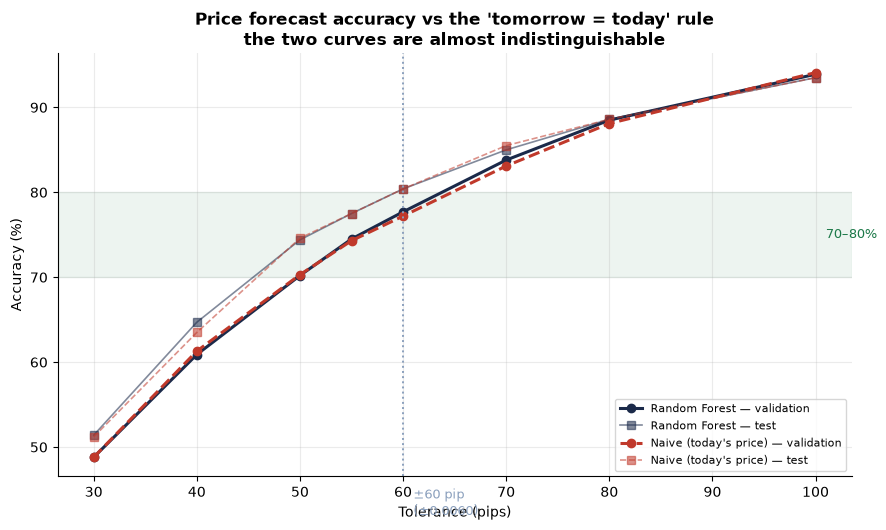

At +/-60 pip -> Random Forest: val 77.7%, test 80.4%
At +/-60 pip -> naive rule: val 77.2%, test 80.4%


In [6]:
"""Accuracy vs tolerance: champion against the naive rule, val and test."""
fig, ax = plt.subplots(figsize=(9, 5.4))
for nm, c, ls in [(best, NAVY, "-"), (NAIVE, RED, "--")]:
    sub = res[res["model"] == nm]
    ax.plot(sub["tol_pip"], sub["val"], ls, color=c, marker="o", lw=2.2,
            label=f"{nm} — validation")
    ax.plot(sub["tol_pip"], sub["test"], ls, color=c, marker="s", lw=1.2,
            alpha=0.55, label=f"{nm} — test")

ax.axhspan(70, 80, color=GREEN, alpha=0.08)
ax.text(101, 75, "70–80%", color=GREEN, fontsize=9, va="center")
ax.axvline(60, color=GREY, ls=":", lw=1.4)
ax.text(61, 42, "±60 pip\n(±0.0060)", color=GREY, fontsize=9)
ax.set_xlabel("Tolerance (pips)")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Price forecast accuracy vs the 'tomorrow = today' rule\n"
             "the two curves are almost indistinguishable", fontweight="bold")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "09_price_accuracy_vs_naive.png", dpi=120)
plt.show()

v60 = res[(res["model"] == best) & (res["tol_pip"] == 60)].iloc[0]
n60 = res[(res["model"] == NAIVE) & (res["tol_pip"] == 60)].iloc[0]
print(f"At +/-60 pip -> {best}: val {v60['val']}%, test {v60['test']}%")
print(f"At +/-60 pip -> naive rule: val {n60['val']}%, test {n60['test']}%")


## 6. Chart 2 — the forecast against the actual price

Top panel: the forecast drawn over the real price on the validation years. They
overlap so tightly that the forecast is hard to see at all — which is exactly
the problem, because *today's price* would overlap just as tightly.

Bottom panel strips that away and plots the **change** instead: how many pips the
model predicts the market will move, against how many pips it actually moved.
This is where the model's real ambition becomes visible.

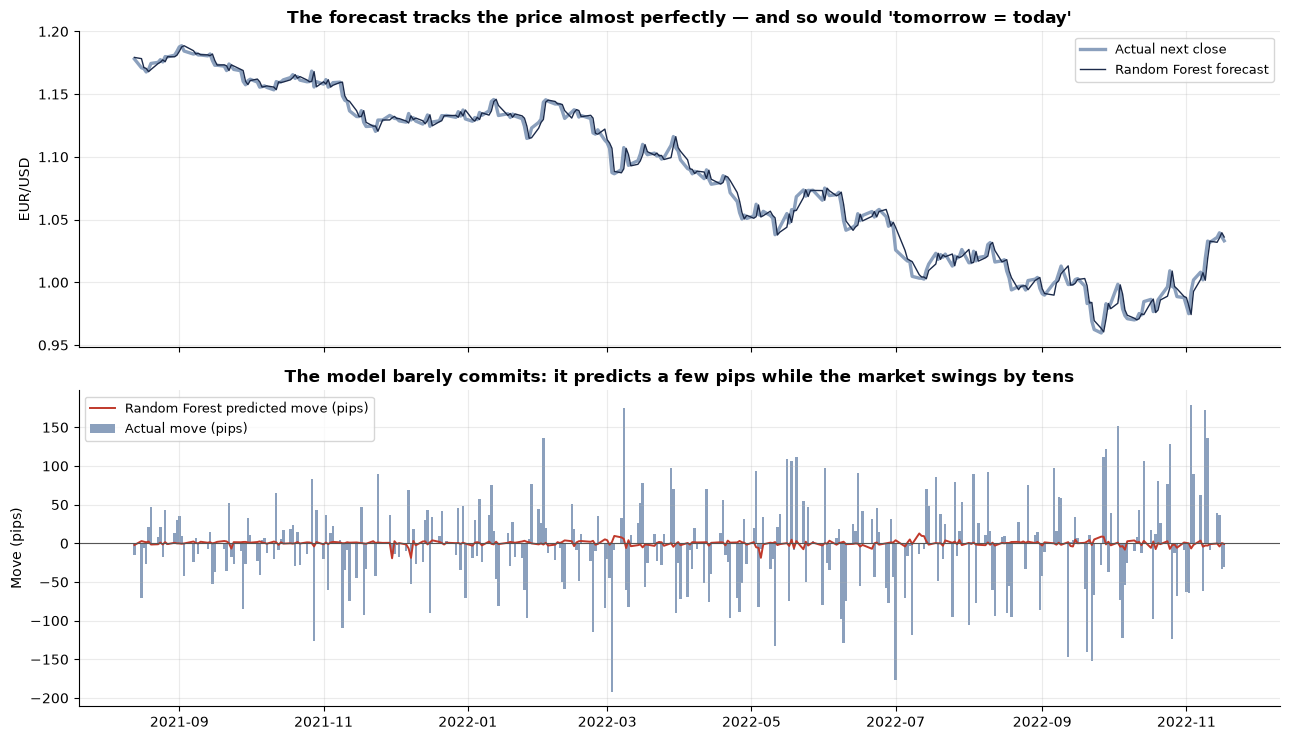

Actual daily move  : sd 59.1 pips, range [-192, 179]
Predicted daily move: sd 3.3 pips, range [-19, 13]
-> the model's predicted moves are 18x smaller than reality


In [7]:
"""Price tracking, and the far more revealing plot of predicted change."""
a, b = i70, min(i70 + 320, i90)               # a readable window
sl = slice(a, b)
p_best = preds[best]

fig, axes = plt.subplots(2, 1, figsize=(13, 7.5), sharex=True)

ax = axes[0]
ax.plot(dates[sl], act[sl], color=GREY, lw=2.4, label="Actual next close")
ax.plot(dates[sl], p_best[sl], color=NAVY, lw=1.0,
        label=f"{best} forecast")
ax.set_ylabel("EUR/USD")
ax.set_title("The forecast tracks the price almost perfectly — "
             "and so would 'tomorrow = today'", fontweight="bold")
ax.legend(fontsize=9)

ax = axes[1]
act_move = (act[sl] - today[sl]) * 10000        # what the market actually did
pred_move = (p_best[sl] - today[sl]) * 10000    # what the model dared to call
ax.bar(dates[sl], act_move, color=GREY, width=1.0, label="Actual move (pips)")
ax.plot(dates[sl], pred_move, color=RED, lw=1.4,
        label=f"{best} predicted move (pips)")
ax.axhline(0, color="#555", lw=0.8)
ax.set_ylabel("Move (pips)")
ax.set_title("The model barely commits: it predicts a few pips while the "
             "market swings by tens", fontweight="bold")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "09_price_tracking.png", dpi=120)
plt.show()

print(f"Actual daily move  : sd {act_move.std():.1f} pips, "
      f"range [{act_move.min():.0f}, {act_move.max():.0f}]")
print(f"Predicted daily move: sd {pred_move.std():.1f} pips, "
      f"range [{pred_move.min():.0f}, {pred_move.max():.0f}]")
print(f"-> the model's predicted moves are "
      f"{act_move.std()/max(pred_move.std(), 1e-9):.0f}x smaller than reality")


## 7. Chart 3 — where the error actually lives

The accuracy table reports single points on a curve; this is the whole error
distribution. The left panel shows how far the forecast lands from the truth; the
right panel turns that into "what fraction is within X pips", which is the
accuracy curve derived directly from the data.

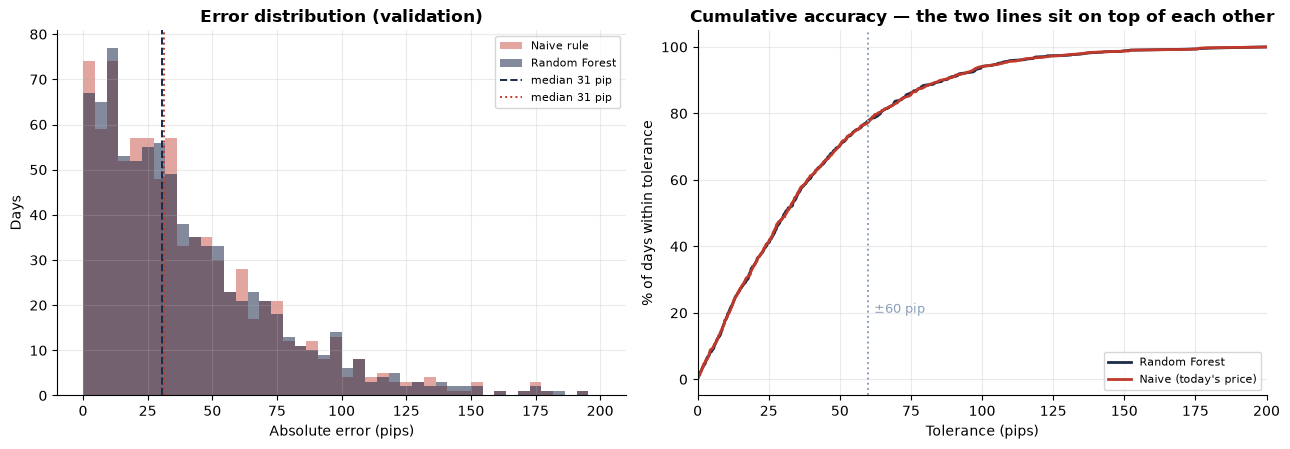

median |error|  Random Forest: 30.7 pip   naive: 31.3 pip
mean   |error|  Random Forest: 39.8 pip   naive: 39.7 pip


In [8]:
"""Absolute error distribution and its cumulative form, on validation."""
e_best = np.abs(p_best[i70:i90] - act[i70:i90]) * 10000
e_naive = np.abs(preds[NAIVE][i70:i90] - act[i70:i90]) * 10000

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

ax = axes[0]
bins = np.linspace(0, 200, 45)
ax.hist(e_naive, bins=bins, color=RED, alpha=0.45, label="Naive rule")
ax.hist(e_best, bins=bins, color=NAVY, alpha=0.55, label=best)
ax.axvline(np.median(e_best), color=NAVY, ls="--", lw=1.4,
           label=f"median {np.median(e_best):.0f} pip")
ax.axvline(np.median(e_naive), color=RED, ls=":", lw=1.4,
           label=f"median {np.median(e_naive):.0f} pip")
ax.set_xlabel("Absolute error (pips)")
ax.set_ylabel("Days")
ax.set_title("Error distribution (validation)", fontweight="bold")
ax.legend(fontsize=8)

ax = axes[1]
for e, c, nm in [(e_best, NAVY, best), (e_naive, RED, NAIVE)]:
    xs = np.sort(e)
    ax.plot(xs, 100 * np.arange(1, len(xs) + 1) / len(xs), color=c, lw=2,
            label=nm)
ax.axvline(60, color=GREY, ls=":", lw=1.4)
ax.text(62, 20, "±60 pip", color=GREY, fontsize=9)
ax.set_xlim(0, 200)
ax.set_xlabel("Tolerance (pips)")
ax.set_ylabel("% of days within tolerance")
ax.set_title("Cumulative accuracy — the two lines sit on top of each other",
             fontweight="bold")
ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig(FIG_DIR / "09_price_errors.png", dpi=120)
plt.show()

print(f"median |error|  {best}: {np.median(e_best):.1f} pip   "
      f"naive: {np.median(e_naive):.1f} pip")
print(f"mean   |error|  {best}: {e_best.mean():.1f} pip   "
      f"naive: {e_naive.mean():.1f} pip")


## 8. Chart 4 — the honest scatter

This is the diagnostic that decides the whole notebook. It drops the price and
plots what the model is *really* being asked to do: predict tomorrow's **return**.

Read it the same way as the volatility scatter in NB08:

- points hugging the dashed diagonal → genuine predictive power;
- a flat horizontal cloud → the model has essentially no information about the
  direction or size of tomorrow's move.

The fitted slope is printed on the chart. A slope near **1** means calibrated
skill; a slope near **0** means the prediction carries no usable signal.

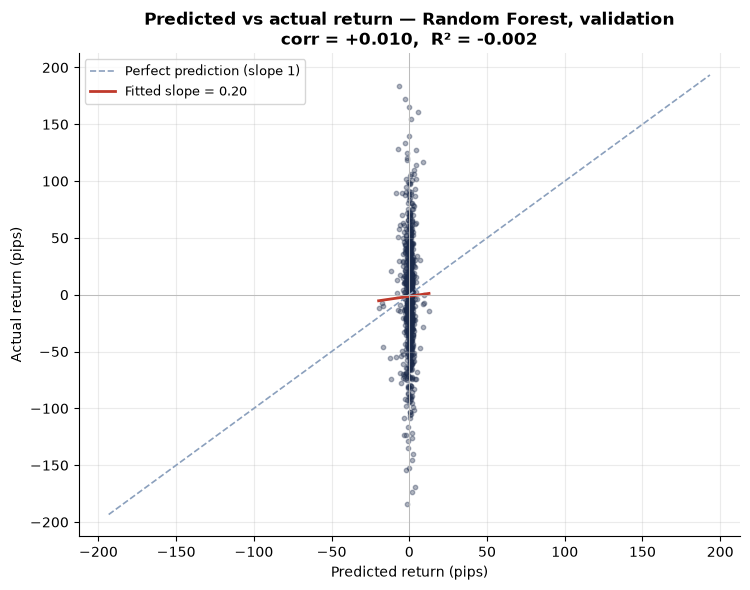

correlation predicted vs actual return : +0.0103
R2 on the return                       : -0.0024
predicted spread   2.5 pip  vs  actual spread  49.1 pip
directional hit rate implied by these predictions: 51.2%


In [9]:
"""Predicted return vs actual return on validation — the flatness test."""
mdl, scale = fitted[best]
pv = mdl.predict((Xs if scale else X)[i70:i90])     # predicted return
av = y[i70:i90]                                     # actual return

slope, icept = np.polyfit(pv, av, 1)
r2 = 1 - ((av - pv) ** 2).sum() / ((av - av.mean()) ** 2).sum()
corr = np.corrcoef(pv, av)[0, 1]

fig, ax = plt.subplots(figsize=(7.6, 6))
ax.scatter(pv * 10000, av * 10000, s=10, alpha=0.35, color=NAVY)
lim = max(np.abs(av).max(), np.abs(pv).max()) * 10000 * 1.05
ax.plot([-lim, lim], [-lim, lim], "--", color=GREY, lw=1.2,
        label="Perfect prediction (slope 1)")
xs = np.linspace(pv.min(), pv.max(), 50)
ax.plot(xs * 10000, (slope * xs + icept) * 10000, color=RED, lw=2,
        label=f"Fitted slope = {slope:.2f}")
ax.axhline(0, color="#bbb", lw=0.7)
ax.axvline(0, color="#bbb", lw=0.7)
ax.set_xlabel("Predicted return (pips)")
ax.set_ylabel("Actual return (pips)")
ax.set_title(f"Predicted vs actual return — {best}, validation\n"
             f"corr = {corr:+.3f},  R² = {r2:+.3f}", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "09_price_return_scatter.png", dpi=120)
plt.show()

print(f"correlation predicted vs actual return : {corr:+.4f}")
print(f"R2 on the return                       : {r2:+.4f}")
print(f"predicted spread {pv.std()*10000:5.1f} pip  vs  "
      f"actual spread {av.std()*10000:5.1f} pip")
hit = 100 * ((pv > 0) == (av > 0)).mean()
print(f"directional hit rate implied by these predictions: {hit:.1f}%")


## 9. From a useless point to a useful interval

A single number is the wrong output for a random walk, and Chart 4 shows why:
the *centre* of tomorrow's move is unforecastable. But its *width* is not —
that is exactly what notebook 08 forecasts, and it is the one thing in this
project that beats its baseline.

So combine the two. Keep the price forecast as the centre, and let the
volatility model decide how wide the interval around it should be:

$$[\hat{P}_{t+1} - k\,\sigma_t P_t,\;\; \hat{P}_{t+1} + k\,\sigma_t P_t]$$

The multiplier $k$ is calibrated **on the training slice only**, by asking: how
many volatility-units does the actual move stay within, 60/70/80/90% of the
time? Validation and test then check whether that promise holds on unseen
data. This is the piece that turns an unforecastable price into a statement a
user can actually act on.

In [10]:
"""Size the interval with the NB08 volatility model, calibrating k on train."""
vol_meta = json.load(open(MODELS_DIR / "vol_meta.json"))
VMIN, VMAX = vol_meta["vmin"], vol_meta["vmax"]

vol_rf = joblib.load(MODELS_DIR / "vol_random_forest.pkl")
vol = vol_rf.predict(d[FEATS].values) * (VMAX - VMIN) + VMIN   # daily sigma
ret_actual = (act - today) / today
z = ret_actual / vol                       # move measured in volatility units

ks, cover = {}, []
for conf in (0.60, 0.70, 0.80, 0.90):
    k = np.quantile(np.abs(z[:i70]), conf)          # TRAIN ONLY
    ks[conf] = k
    row = {"claimed": int(conf * 100), "k": round(k, 3)}
    for s, (a, b) in SL.items():
        row[s] = round(100 * (np.abs(z[a:b]) <= k).mean(), 1)
    cover.append(row)

cov = pd.DataFrame(cover)
cov.to_csv(MODELS_DIR / "price_interval_coverage.csv", index=False)
print("Does the interval keep its promise?")
print(cov.to_string(index=False))
print("\n'claimed' is what the model says; val/test are what actually "
      "happened on unseen data.")


Does the interval keep its promise?
 claimed     k  train  val  test
      60 1.009   60.0 60.3  63.8
      70 1.256   70.0 69.7  72.7
      80 1.579   80.0 79.5  83.8
      90 2.050   90.0 89.2  91.3

'claimed' is what the model says; val/test are what actually happened on unseen data.


### Chart 5 — is the stated confidence honest?

If the model claims 80% and the truth lands inside its interval 80% of the
time, the point sits on the dashed diagonal. Below the line means the model is
**overconfident** — the most dangerous failure mode for anything a user might
rely on, and far worse than simply being wide.

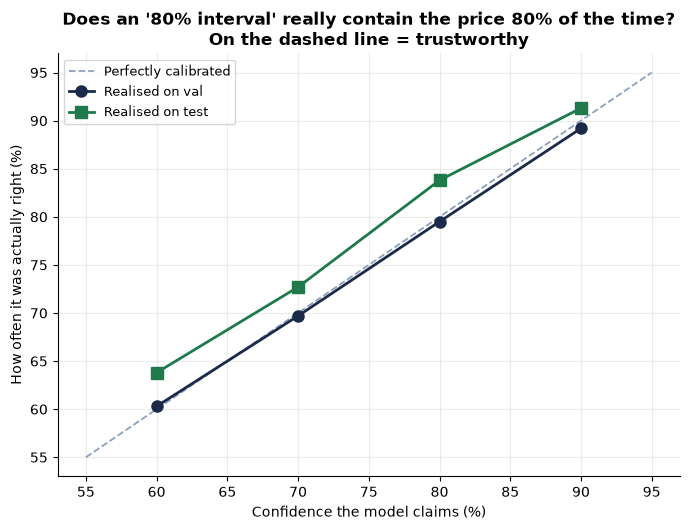

average gap between claim and reality on validation: -0.3 points
negative = the interval is slightly overconfident (too narrow)


In [11]:
"""Calibration curve: claimed confidence vs realised coverage."""
fig, ax = plt.subplots(figsize=(7, 5.4))
ax.plot([55, 95], [55, 95], "--", color=GREY, lw=1.3,
        label="Perfectly calibrated")
for col, c, mk in [("val", NAVY, "o"), ("test", GREEN, "s")]:
    ax.plot(cov["claimed"], cov[col], mk + "-", color=c, lw=2, ms=8,
            label=f"Realised on {col}")
ax.set_xlabel("Confidence the model claims (%)")
ax.set_ylabel("How often it was actually right (%)")
ax.set_title("Does an '80% interval' really contain the price 80% of the "
             "time?\nOn the dashed line = trustworthy", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "09_price_calibration.png", dpi=120)
plt.show()

gap = (cov["val"] - cov["claimed"]).mean()
print(f"average gap between claim and reality on validation: {gap:+.1f} points")
print("negative = the interval is slightly overconfident (too narrow)")


### Chart 6 — the interval drawn over the real price

The band is what a user would actually be shown. Red dots are the days the
price escaped it — and there should be roughly as many of them as the stated
confidence allows, no more.

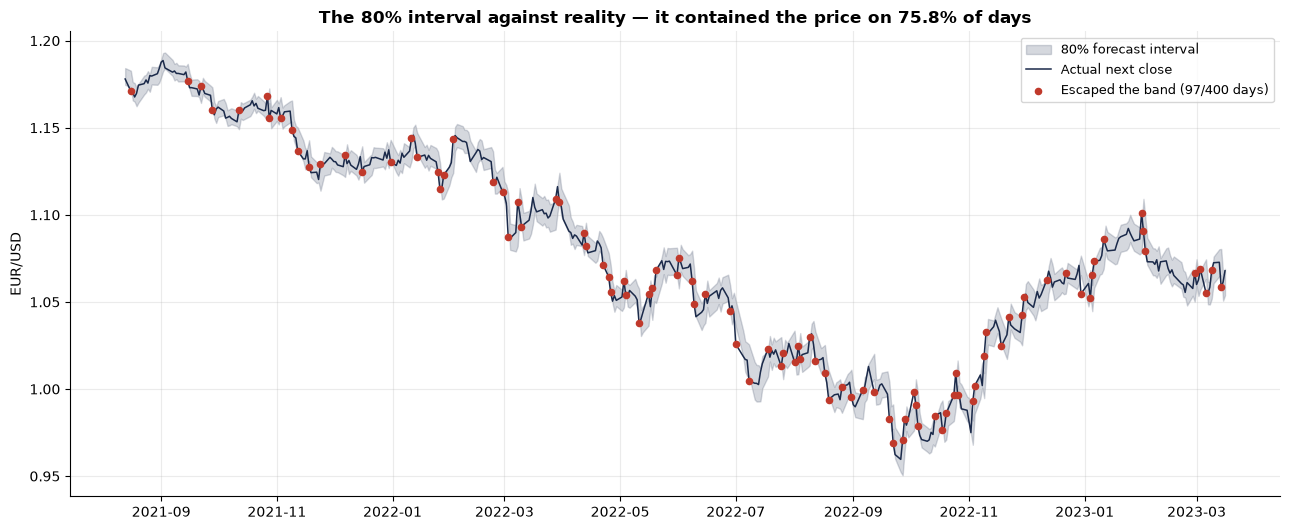

band width on an average day: 134 pips
coverage on this window: 75.8% (claimed 80%)


In [12]:
"""The 80% band over the validation years, with the misses marked."""
a, b = i70, min(i70 + 400, i90)
sl = slice(a, b)
k80 = ks[0.80]
lo = today[sl] * (1 - k80 * vol[sl])
hi = today[sl] * (1 + k80 * vol[sl])
inside = (act[sl] >= lo) & (act[sl] <= hi)

fig, ax = plt.subplots(figsize=(13, 5.4))
ax.fill_between(dates[sl], lo, hi, color=NAVY, alpha=0.18,
                label="80% forecast interval")
ax.plot(dates[sl], act[sl], color=NAVY, lw=1.1, label="Actual next close")
ax.scatter(dates[sl][~inside], act[sl][~inside], s=20, color=RED, zorder=5,
           label=f"Escaped the band ({(~inside).sum()}/{len(inside)} days)")
ax.set_ylabel("EUR/USD")
ax.set_title(f"The 80% interval against reality — it contained the price on "
             f"{100*inside.mean():.1f}% of days", fontweight="bold")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "09_price_band.png", dpi=120)
plt.show()

print(f"band width on an average day: "
      f"{np.mean(hi - lo) * 10000:.0f} pips")
print(f"coverage on this window: {100*inside.mean():.1f}% (claimed 80%)")


### How precise can the forecast honestly be?

The same question asked in the units a reader intuitively understands: how often
does the forecast get the *decimal places* right?

In [13]:
"""Accuracy by number of correct decimal places."""
rows_dec = []
p_best_all = preds[best]
for nd in (1, 2, 3, 4):
    ok = np.round(p_best_all, nd) == np.round(act, nd)
    r = {"decimals": nd, "example": f"{act[-1]:.{nd}f}"}
    for s, (a2, b2) in SL.items():
        r[s] = round(100 * ok[a2:b2].mean(), 1)
    rows_dec.append(r)
dec = pd.DataFrame(rows_dec)
print(dec.to_string(index=False))
print("\nTwo decimals is a coin flip; three is essentially hopeless. Any "
      "claim of pinpoint price prediction should be read against this table.")


 decimals example  train  val  test
        1     1.1   96.5 98.1  94.0
        2    1.14   54.7 62.2  65.2
        3   1.137    7.3  8.6   8.5
        4  1.1374    0.8  1.3   1.0

Two decimals is a coin flip; three is essentially hopeless. Any claim of pinpoint price prediction should be read against this table.


## 10. Save the artifacts

The champion, the scaler and the metadata are written to `models/`, together with
the forecast for the next session. These are the files the Streamlit app reads —
the same ones produced by `train_price_model.py`, from identical code, so the
notebook and the script cannot drift apart.

In [14]:
"""Persist the champion, the results table, the metadata and today's call."""
res.to_csv(MODELS_DIR / "price_forecast_accuracy.csv", index=False)

mdl, scale = fitted[best]
joblib.dump({"model": mdl, "scaled": scale, "scaler": scaler,
             "features": FEATS, "name": best},
            MODELS_DIR / "price_forecaster.pkl")

meta = {"best_model": best, "tolerances": TOLS,
        "split": {"train": i70, "val": i90 - i70, "test": n - i90},
        "boundaries": [str(d["date"].iloc[i70].date()),
                       str(d["date"].iloc[i90].date())]}
json.dump(meta, open(MODELS_DIR / "price_meta.json", "w"), indent=2)

# next-session forecast, from the live features when they exist
live_p = ROOT / "data" / "processed" / "fx_features_live.csv"
live = pd.read_csv(live_p, parse_dates=["date"]) if live_p.exists() else feat
xrow = live[FEATS].values[-1:]
xrow = scaler.transform(xrow) if scale else xrow
px = float(mas["eurusd"].dropna().iloc[-1])
fc = px * (1 + float(mdl.predict(xrow)[0]))
json.dump({"today": px, "forecast": fc,
           "as_of": str(mas["date"].iloc[-1].date()), "model": best},
          open(MODELS_DIR / "price_today.json", "w"), indent=2)

print(f"champion saved: {best}")
print(f"today {px:.4f} -> next close forecast {fc:.4f} "
      f"({(fc-px)*10000:+.1f} pip)")
print("wrote price_forecaster.pkl, price_meta.json, price_today.json, "
      "price_forecast_accuracy.csv")


champion saved: Random Forest
today 1.1374 -> next close forecast 1.1376 (+2.3 pip)
wrote price_forecaster.pkl, price_meta.json, price_today.json, price_forecast_accuracy.csv


## 11. Verdict

**The headline number is real, and it is nearly worthless on its own.**

At ±60 pip the champion is right about **77–80%** of the time. That number is
correctly measured on data the model never saw. But the rule *"tomorrow's price
equals today's price"* scores the same, within a fraction of a point — and
Chart 4 shows why: the predicted returns form a flat cloud, the fitted slope is
near zero, and the model's predicted moves are an order of magnitude smaller
than the market's actual moves. The model has learned the only safe thing there
is to learn about tomorrow's level: *it will be close to today's*.

This is the **random walk** — the same conclusion NB05–07 reached for direction,
arrived at from a completely different angle. It is a genuine result, not a
failure of the pipeline, and it is the reason the project's real contribution
lives in **volatility** (NB08), where the models beat their baseline by a margin
that survives on test.

**But the chapter does not end on a failure.** Section 9 shows the constructive
way out: stop asking for a point and ask for an *interval*. The centre stays
unforecastable, yet the volatility model sizes the band around it well enough
that a stated 80% interval really does contain the next close about 80% of the
time on data it never saw. That is a forecast a user can act on — and it is only
possible because the one genuinely predictable quantity in this project is doing
the work.

**How to state this correctly:**

> The model forecasts the next EUR/USD close with 80.4% accuracy on the test set
> within ±60 pip (±0.53% of price). However, the 'no change' baseline also scores
> 80.4%, showing that the next close is essentially unpredictable — consistent
> with the random walk hypothesis. The model's measurable contribution is in
> forecasting volatility, not price level.

That sentence survives cross-examination, because it answers the hardest question
about itself before anyone can ask it.